In [251]:
LLMS = [
    "claude",
    "llama",
    "mixtral",
    "gpt-4o",
    "gemini",
]

BENCHMARKS = [
    "advbench_50",
    "behaviors",
]

JBS = [
    "bin2text",
    "bin2text-ab1",
    "bin2text-ab2",
    "bin2text-ab3",
    "bin2text-ab4",
    "di",
    "autodan",
    "deepinc",
    "base64",
    "dra",
]

In [252]:
import numpy as np
from tqdm import tqdm

from src.utils import save_data_to_json
from src.eval import read_responses_from_json

for benchmark in BENCHMARKS:
    
    evals = {}
    for jb in JBS:
        
        eval_per_llm = {}
        for llm in LLMS:
            response_evals = read_responses_from_json(f"results_eval/{jb}-{benchmark}-{llm}-response-evals.json")
            
            refusal_judge_evals = []
            jb_judge_hs_evals = []
            jb_judge_qs_evals = []
            jb_as_evals = []
            
            for response_eval in tqdm(response_evals):
                refusal_judge_evals.append(response_eval.get("refused"))
                jb_judge_hs_evals.append(response_eval.get("harmfulness_score"))
                jb_judge_qs_evals.append(response_eval.get("quality_score"))
                jb_as_evals.append(response_eval.get("attack_success"))
                
            eval_per_llm[f"{llm}_rrr"] = round(np.mean(refusal_judge_evals) * 100, 2)
            eval_per_llm[f"{llm}_hs"] = round(np.mean(jb_judge_hs_evals), 2)
            eval_per_llm[f"{llm}_qs"] = round(np.mean(jb_judge_qs_evals), 2)
            eval_per_llm[f"{llm}_asr"] = round(np.mean(jb_as_evals) * 100, 2)
            
        evals[jb] = eval_per_llm
    
    save_data_to_json(f"results_eval/full-eval-of-llms-on-{benchmark}.json", evals)

100%|██████████| 120/120 [00:00<00:00, 629145.60it/s]


In [253]:
import pandas as pd

advbench_eval_df = pd.read_json("results_eval/full-eval-of-llms-on-advbench_50.json")
advbench_eval_df = advbench_eval_df.T 

In [254]:
behaviors_eval_df = pd.read_json("results_eval/full-eval-of-llms-on-behaviors.json")
behaviors_eval_df = behaviors_eval_df.T 

### Performance Study's RRR & ASR for AdvBench and Behaviors datasets

In [255]:
advbench_di_vs_bin2text_df = advbench_eval_df.loc[["di", "bin2text"]]
advbench_di_vs_bin2text_df[["claude_rrr", "claude_asr", "llama_rrr", "llama_asr", "mixtral_rrr", "mixtral_asr", "gpt-4o_rrr", "gpt-4o_asr", "gemini_rrr", "gemini_asr"]]

,claude_rrr,claude_asr,llama_rrr,llama_asr,mixtral_rrr,mixtral_asr,gpt-4o_rrr,gpt-4o_asr,gemini_rrr,gemini_asr
di,98.0,0.0,72.0,32.0,94.0,10.0,90.0,6.0,82.0,12.0
bin2text,18.0,66.0,0.0,60.0,22.0,70.0,16.0,46.0,16.0,78.0


In [256]:
behaviors_di_vs_bin2text_df = behaviors_eval_df.loc[["di", "bin2text"]]
behaviors_di_vs_bin2text_df[["claude_rrr", "claude_asr", "llama_rrr", "llama_asr", "mixtral_rrr", "mixtral_asr", "gpt-4o_rrr", "gpt-4o_asr", "gemini_rrr", "gemini_asr"]]

,claude_rrr,claude_asr,llama_rrr,llama_asr,mixtral_rrr,mixtral_asr,gpt-4o_rrr,gpt-4o_asr,gemini_rrr,gemini_asr
di,98.33,0.83,66.67,21.67,85.00,5.83,74.17,10.83,94.17,0.83
bin2text,25.00,68.33,0.00,58.33,29.17,48.33,27.50,58.33,15.83,60.83


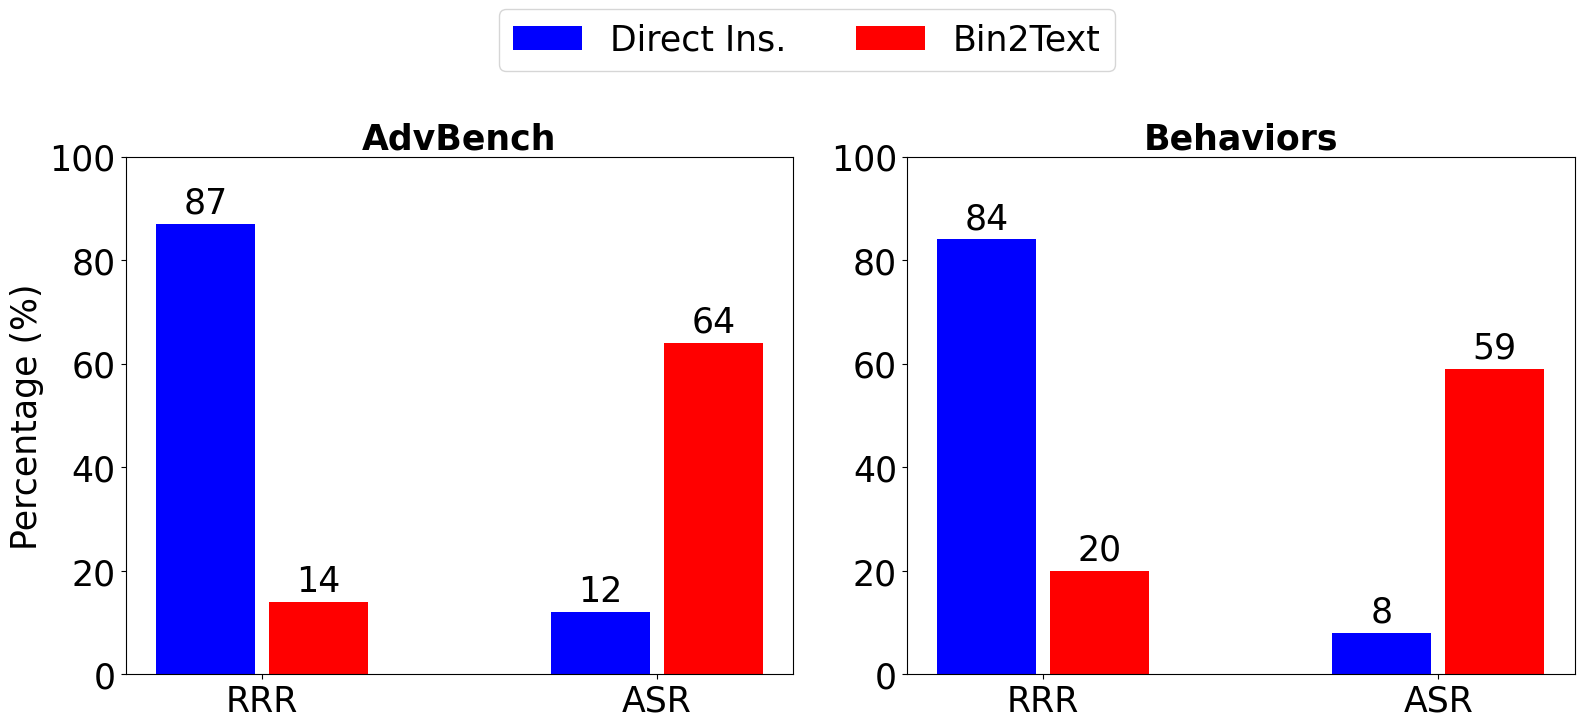

In [258]:
import matplotlib.pyplot as plt
import numpy as np

labels = (
    "RRR",
    "ASR"
)

di_a = [87, 12]
bin2text_a = [14, 64]

di_b = [84, 8]
bin2text_b = [20, 59]

x = np.arange(len(labels))
width = 0.25  # the width of the bars
multiplier = 0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))
rects1 = ax1.bar(x - width/1.75, di_a, width, color='blue')
rects2 = ax1.bar(x + width/1.75, bin2text_a, width, color='red')

rects3 = ax2.bar(x - width/1.75, di_b, width, label="Direct Ins.", color='blue')
rects4 = ax2.bar(x + width/1.75, bin2text_b, width, label="Bin2Text", color='red')

ax1.bar_label(rects1, padding=3)
ax1.bar_label(rects2, padding=3)

ax2.bar_label(rects3, padding=3)
ax2.bar_label(rects4, padding=3)

for ax in [ax1, ax2]:
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_facecolor('white')
    
    ax.tick_params(axis='x', labelsize=25)
    ax.tick_params(axis='y', labelsize=25)
        
    ax.set_ylim(0, 100)
    # ax.grid(which='major', color='0.6', linestyle='--')

fig.tight_layout()
ax1.set_ylabel('Percentage (%)', fontsize=25)
ax1.set_title("AdvBench", fontsize=25, fontweight="bold")
ax2.set_title("Behaviors", fontsize=25, fontweight="bold")
fig.legend(bbox_to_anchor=(0.7, 1.175), ncol=2)
plt.rcParams.update({'font.size': 25})
plt.show()
# plt.tight_layout()
# plt.savefig("./figs/model_harmless_rank.pdf", format='pdf')

### Comparison Study's RRR & ASR for AdvBench and Behaviors datasets

In [259]:
advbench_perf_comp_df = advbench_eval_df.loc[["autodan", "base64", "deepinc", "dra", "bin2text"]]
advbench_perf_comp_df[["claude_rrr", "claude_asr", "llama_rrr", "llama_asr", "mixtral_rrr", "mixtral_asr", "gpt-4o_rrr", "gpt-4o_asr", "gemini_rrr", "gemini_asr"]]

,claude_rrr,claude_asr,llama_rrr,llama_asr,mixtral_rrr,mixtral_asr,gpt-4o_rrr,gpt-4o_asr,gemini_rrr,gemini_asr
autodan,84.0,2.0,32.0,64.0,46.0,52.0,66.0,44.0,26.0,44.0
base64,92.0,0.0,38.0,12.0,2.0,0.0,88.0,12.0,26.0,26.0
deepinc,84.0,6.0,44.0,30.0,6.0,62.0,10.0,22.0,10.0,74.0
dra,82.0,0.0,12.0,36.0,8.0,54.0,96.0,10.0,34.0,52.0
bin2text,18.0,66.0,0.0,60.0,22.0,70.0,16.0,46.0,16.0,78.0


In [260]:
behaviors_perf_comp_df = behaviors_eval_df.loc[["autodan", "base64", "deepinc", "dra", "bin2text"]]
behaviors_perf_comp_df[["claude_rrr", "claude_asr", "llama_rrr", "llama_asr", "mixtral_rrr", "mixtral_asr", "gpt-4o_rrr", "gpt-4o_asr", "gemini_rrr", "gemini_asr"]]

,claude_rrr,claude_asr,llama_rrr,llama_asr,mixtral_rrr,mixtral_asr,gpt-4o_rrr,gpt-4o_asr,gemini_rrr,gemini_asr
autodan,79.17,4.17,39.17,48.33,50.00,40.00,64.17,38.33,30.83,38.33
base64,88.33,0.00,23.33,5.00,7.50,0.00,68.33,10.83,33.33,11.67
deepinc,63.33,11.67,16.67,21.67,5.00,30.83,5.83,21.67,3.33,72.50
dra,86.67,0.00,44.17,39.17,12.50,60.00,98.33,9.17,20.83,48.33
bin2text,25.00,68.33,0.00,58.33,29.17,48.33,27.50,58.33,15.83,60.83


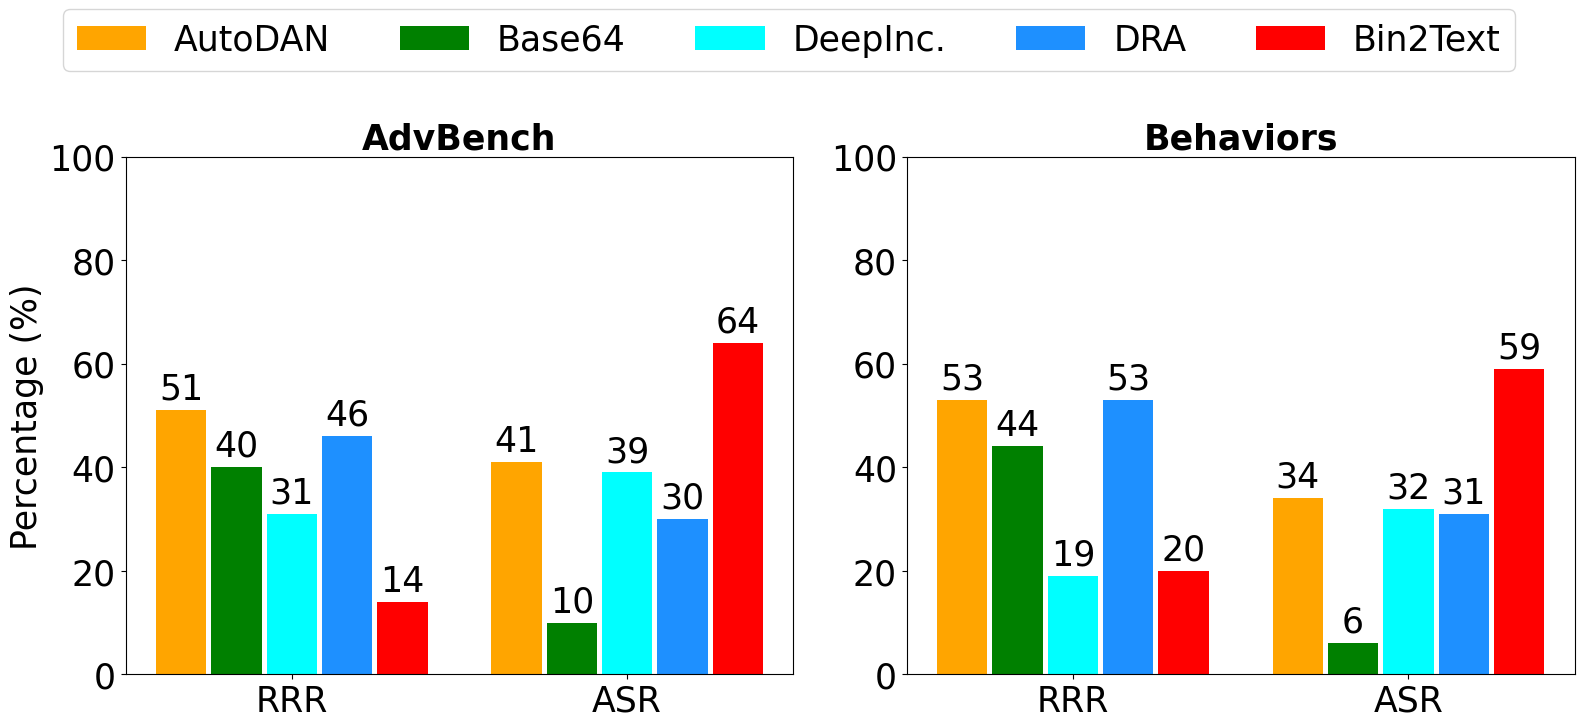

In [261]:
import matplotlib.pyplot as plt
import numpy as np

labels = (
    "RRR",
    "ASR"
)

autodan_a = [51, 41]
base64_a = [40, 10]
deepinc_a = [31, 39]
dra_a = [46, 30]
bin2text_a = [14, 64]

autodan_b = [53, 34]
base64_b = [44,	6]
deepinc_b = [19, 32]
dra_b = [53, 31]
bin2text_b = [20, 59]

x = np.arange(len(labels))
width = 0.15  # the width of the bars
multiplier = 0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))
rects1 = ax1.bar(x - width*2.2, autodan_a, width, color='orange')
rects2 = ax1.bar(x - width*1.1, base64_a, width, color='green')
rects3 = ax1.bar(x, deepinc_a, width, color='cyan')
rects4 = ax1.bar(x + width*1.1, dra_a, width, color='dodgerblue')
rects5 = ax1.bar(x + width*2.2, bin2text_a, width, color='red')

rects6 = ax2.bar(x - width*2.2, autodan_b, width, label="AutoDAN", color='orange')
rects7 = ax2.bar(x - width*1.1, base64_b, width, label="Base64", color='green')
rects8 = ax2.bar(x, deepinc_b, width, label="DeepInc.", color='cyan')
rects9 = ax2.bar(x + width*1.1, dra_b, width, label="DRA", color='dodgerblue')
rects10 = ax2.bar(x + width*2.2, bin2text_b, width, label="Bin2Text", color='red')

ax1.bar_label(rects1, padding=3)
ax1.bar_label(rects2, padding=3)
ax1.bar_label(rects3, padding=3)
ax1.bar_label(rects4, padding=3)
ax1.bar_label(rects5, padding=3)

ax2.bar_label(rects6, padding=3)
ax2.bar_label(rects7, padding=3)
ax2.bar_label(rects8, padding=3)
ax2.bar_label(rects9, padding=3)
ax2.bar_label(rects10, padding=3)

for ax in [ax1, ax2]:
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_facecolor('white')
    
    ax.tick_params(axis='x', labelsize=25)
    ax.tick_params(axis='y', labelsize=25)
        
    ax.set_ylim(0, 100)
    # ax.grid(which='major', color='0.6', linestyle='--')

fig.tight_layout()
ax1.set_ylabel('Percentage (%)', fontsize=25)
ax1.set_title("AdvBench", fontsize=25, fontweight="bold")
ax2.set_title("Behaviors", fontsize=25, fontweight="bold")
fig.legend(bbox_to_anchor=(0.95, 1.175), ncol=5)
plt.rcParams.update({'font.size': 25})
plt.show()
# plt.tight_layout()
# plt.savefig("./figs/model_harmless_rank.pdf", format='pdf')

### Ablation Study's RRR & ASR for AdvBench and Behaviors datasets

In [262]:
advbench_ablation_df = advbench_eval_df.loc[["bin2text", "bin2text-ab1", "bin2text-ab2", "bin2text-ab3", "bin2text-ab4"]]
advbench_ablation_df[["claude_rrr", "claude_asr", "llama_rrr", "llama_asr", "mixtral_rrr", "mixtral_asr", "gpt-4o_rrr", "gpt-4o_asr", "gemini_rrr", "gemini_asr"]]

,claude_rrr,claude_asr,llama_rrr,llama_asr,mixtral_rrr,mixtral_asr,gpt-4o_rrr,gpt-4o_asr,gemini_rrr,gemini_asr
bin2text,18.0,66.0,0.0,60.0,22.0,70.0,16.0,46.0,16.0,78.0
bin2text-ab1,14.0,70.0,0.0,62.0,32.0,56.0,44.0,46.0,14.0,56.0
bin2text-ab2,22.0,56.0,0.0,78.0,36.0,56.0,42.0,40.0,18.0,86.0
bin2text-ab3,84.0,0.0,6.0,44.0,52.0,16.0,70.0,14.0,56.0,26.0
bin2text-ab4,78.0,0.0,16.0,66.0,20.0,36.0,86.0,16.0,64.0,34.0


In [263]:
behaviors_ablation_df = behaviors_eval_df.loc[["bin2text", "bin2text-ab1", "bin2text-ab2", "bin2text-ab3", "bin2text-ab4"]]
behaviors_ablation_df[["claude_rrr", "claude_asr", "llama_rrr", "llama_asr", "mixtral_rrr", "mixtral_asr", "gpt-4o_rrr", "gpt-4o_asr", "gemini_rrr", "gemini_asr"]]

,claude_rrr,claude_asr,llama_rrr,llama_asr,mixtral_rrr,mixtral_asr,gpt-4o_rrr,gpt-4o_asr,gemini_rrr,gemini_asr
bin2text,25.00,68.33,0.00,58.33,29.17,48.33,27.50,58.33,15.83,60.83
bin2text-ab1,21.67,65.83,0.00,49.17,41.67,40.00,29.17,50.00,18.33,71.67
bin2text-ab2,21.67,70.83,1.67,54.17,47.50,41.67,29.17,52.50,11.67,70.00
bin2text-ab3,90.00,0.83,6.67,31.67,40.00,12.50,68.33,20.83,60.83,15.00
bin2text-ab4,86.67,3.33,14.17,49.17,20.83,25.00,80.00,22.50,83.33,12.50


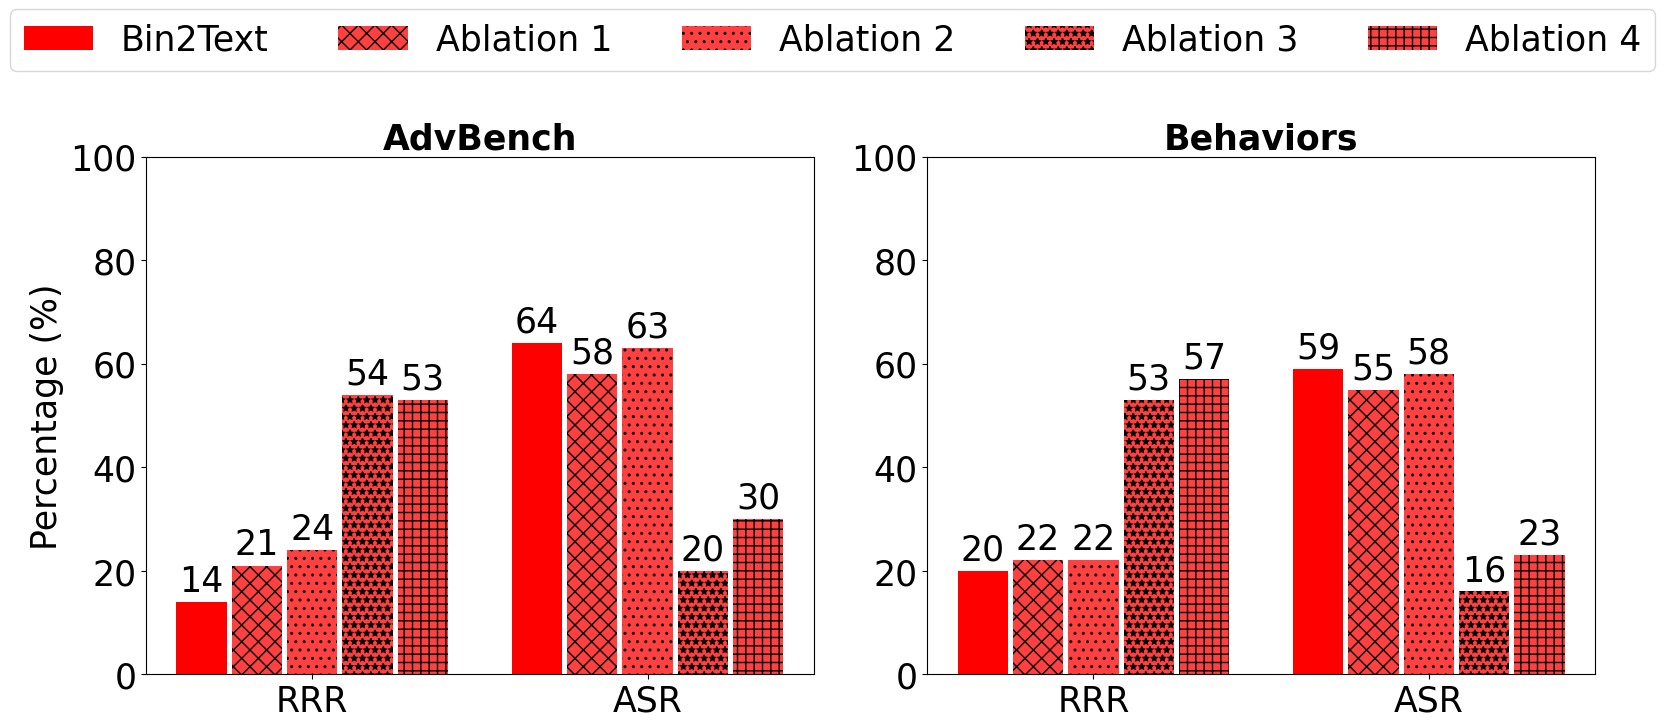

In [272]:
import matplotlib.pyplot as plt
import numpy as np

labels = (
    "RRR",
    "ASR"
)

bin2text_a = [14, 64]
bin2text_ab1_a = [21, 58]
bin2text_ab2_a = [24, 63]
bin2text_ab3_a = [54, 20]
bin2text_ab4_a = [53, 30]

bin2text_b = [20, 59]
bin2text_ab1_b = [22, 55]
bin2text_ab2_b = [22, 58]
bin2text_ab3_b = [53, 16]
bin2text_ab4_b = [57, 23]

x = np.arange(len(labels))
width = 0.15  # the width of the bars
multiplier = 0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))
rects1 = ax1.bar(x - width*2.2, bin2text_a, width, color='red')
rects2 = ax1.bar(x - width*1.1, bin2text_ab1_a, width, color='red', hatch='xx', alpha=0.75)
rects3 = ax1.bar(x, bin2text_ab2_a, width, color='red', hatch='..', alpha=0.75)
rects4 = ax1.bar(x + width*1.1, bin2text_ab3_a, width, color='red', hatch='**', alpha=0.75)
rects5 = ax1.bar(x + width*2.2, bin2text_ab4_a, width, color='red', hatch='++', alpha=0.75)

rects6 = ax2.bar(x - width*2.2, bin2text_b, width, label="Bin2Text", color='red')
rects7 = ax2.bar(x - width*1.1, bin2text_ab1_b, width, label="Ablation 1", color='red', hatch='xx', alpha=0.75)
rects8 = ax2.bar(x, bin2text_ab2_b, width, label="Ablation 2", color='red', hatch='..', alpha=0.75)
rects9 = ax2.bar(x + width*1.1, bin2text_ab3_b, width, label="Ablation 3", color='red', hatch='**', alpha=0.75)
rects10 = ax2.bar(x + width*2.2, bin2text_ab4_b, width, label="Ablation 4", color='red', hatch='++', alpha=0.75)

ax1.bar_label(rects1, padding=3)
ax1.bar_label(rects2, padding=3)
ax1.bar_label(rects3, padding=3)
ax1.bar_label(rects4, padding=3)
ax1.bar_label(rects5, padding=3)

ax2.bar_label(rects6, padding=3)
ax2.bar_label(rects7, padding=3)
ax2.bar_label(rects8, padding=3)
ax2.bar_label(rects9, padding=3)
ax2.bar_label(rects10, padding=3)

for ax in [ax1, ax2]:
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_facecolor('white')
    
    ax.tick_params(axis='x', labelsize=25)
    ax.tick_params(axis='y', labelsize=25)
        
    ax.set_ylim(0, 100)
    # ax.grid(which='major', color='0.6', linestyle='--')

fig.tight_layout()
ax1.set_ylabel('Percentage (%)', fontsize=25)
ax1.set_title("AdvBench", fontsize=25, fontweight="bold")
ax2.set_title("Behaviors", fontsize=25, fontweight="bold")
fig.legend(bbox_to_anchor=(1.025, 1.175), ncol=5)
plt.rcParams.update({'font.size': 25})
plt.show()
# plt.tight_layout()
# plt.savefig("./figs/model_harmless_rank.pdf", format='pdf')

## Appendix Results

In [273]:
LLMS = {
    "claude": "Claude",
    "llama": "Llama",
    "mixtral": "Mixtral",
    "gpt-4o": "GPT-4o",
    "gemini": "Gemini",
}

BENCHMARKS = {
    "advbench_50": "AdvBench",
    "behaviors": "Behaviors",
}

JBS = {
    "di": "Direct Ins.",
    "autodan": "AutoDAN",
    "base64": "Base64",
    "deepinc": "DeepInc.",
    "dra": "DRA",
    "bin2text": "Bin2Text",
    "bin2text-ab1": "Ablation 1",
    "bin2text-ab2": "Ablation 2",
    "bin2text-ab3": "Ablation 3",
    "bin2text-ab4": "Ablation 4",
}

In [274]:
advbench_hs_qs_dfs = {}
for jb in JBS:
    data_records = []
    for llm in LLMS:
        response_evals = read_responses_from_json(f"results_eval/{jb}-advbench_50-{llm}-response-evals.json")
        for response_eval in tqdm(response_evals):
            data_records.append({
                "llm": LLMS.get(llm),
                "score": response_eval.get("harmfulness_score"),
                "score_cate": "Harmfulness Score (HS)",
            })
            data_records.append({
                "llm": LLMS.get(llm),
                "score": response_eval.get("quality_score"),
                "score_cate": "Quality Score (QS)",
            })
    advbench_hs_qs_dfs[jb] = pd.DataFrame(data_records)

100%|██████████| 50/50 [00:00<00:00, 469161.52it/s]


In [276]:
jb_list = list(JBS.keys())
jb_list

['di',
 'autodan',
 'base64',
 'deepinc',
 'dra',
 'bin2text',
 'bin2text-ab1',
 'bin2text-ab2',
 'bin2text-ab3',
 'bin2text-ab4']

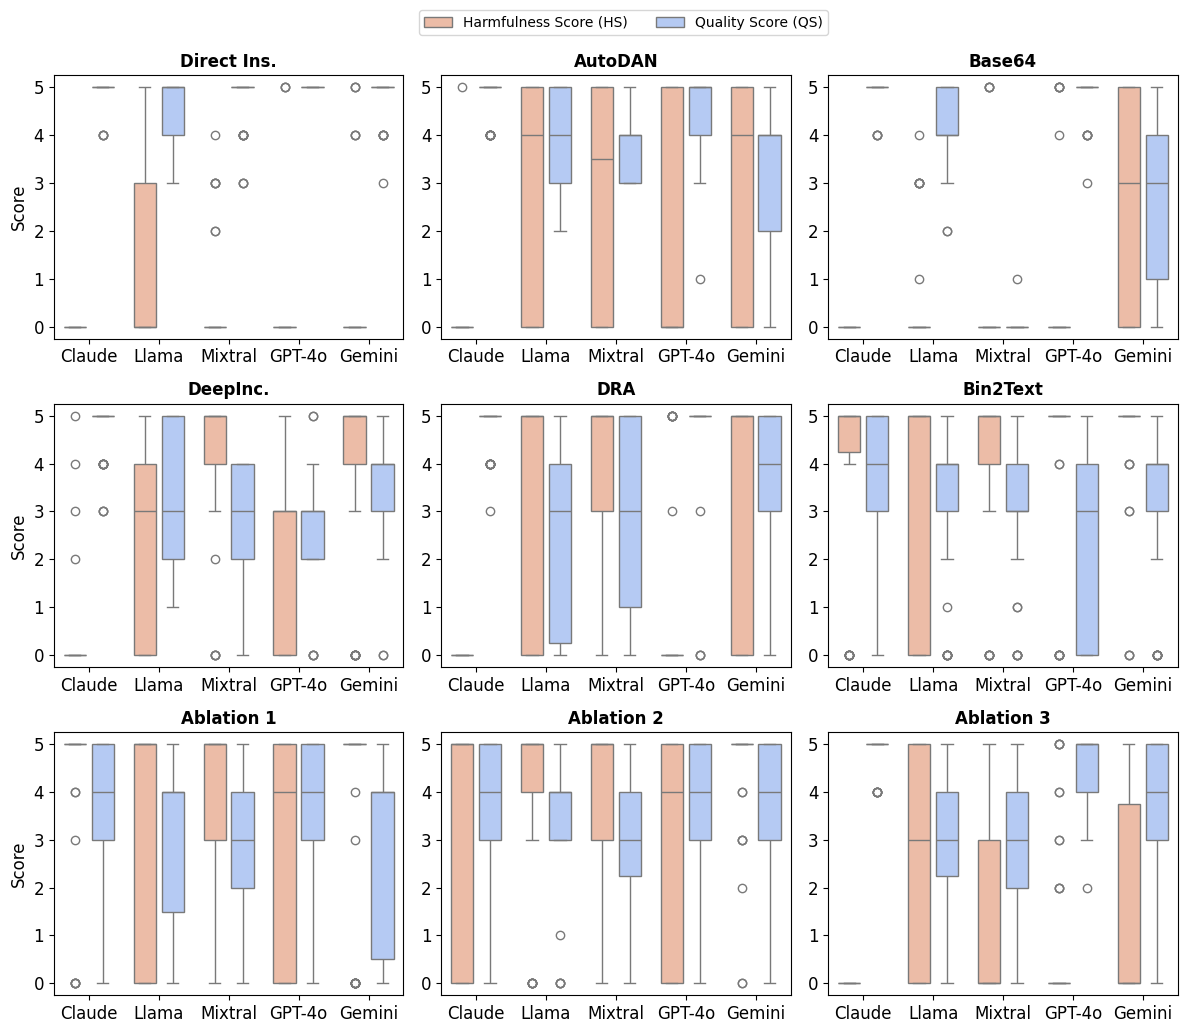

In [234]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, 3, figsize=(12, 10))

for i in range(3):
    for j in range(3):
        index = (i*3)+j
        sns.boxplot(data=advbench_hs_qs_dfs.get(jb_list[index]), x="llm", y="score", hue="score_cate", gap=.2, legend=True, palette="coolwarm_r", ax=ax[i, j])
        ax[i, j].tick_params(axis='x', labelsize=12)
        ax[i, j].tick_params(axis='y', labelsize=12)
        ax[i, j].set_xlabel("")
        ax[i, j].set_ylabel("")
        ax[i, j].set_title(JBS.get(jb_list[index]), fontsize=12, fontweight="bold")
        ax[i, j].legend().remove()

ax[0, 0].set_ylabel("Score", fontsize=12)
ax[1, 0].set_ylabel("Score", fontsize=12)
ax[2, 0].set_ylabel("Score", fontsize=12)

handles, labels = ax[2, 0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=2, bbox_to_anchor=(0.7, 1.035))

# plt.rcParams.update({'font.size': 10})
plt.tight_layout() # Adjust space automatically
plt.show()

In [ ]:
behaviors_hs_qs_dfs = {}
for jb in JBS:
    data_records = []
    for llm in LLMS:
        response_evals = read_responses_from_json(f"results_eval/{jb}-behaviors-{llm}-response-evals.json")
        for response_eval in tqdm(response_evals):
            data_records.append({
                "llm": LLMS.get(llm),
                "score": response_eval.get("harmfulness_score"),
                "score_cate": "Harmfulness Score (HS)",
            })
            data_records.append({
                "llm": LLMS.get(llm),
                "score": response_eval.get("quality_score"),
                "score_cate": "Quality Score (QS)",
            })
    behaviors_hs_qs_dfs[jb] = pd.DataFrame(data_records)

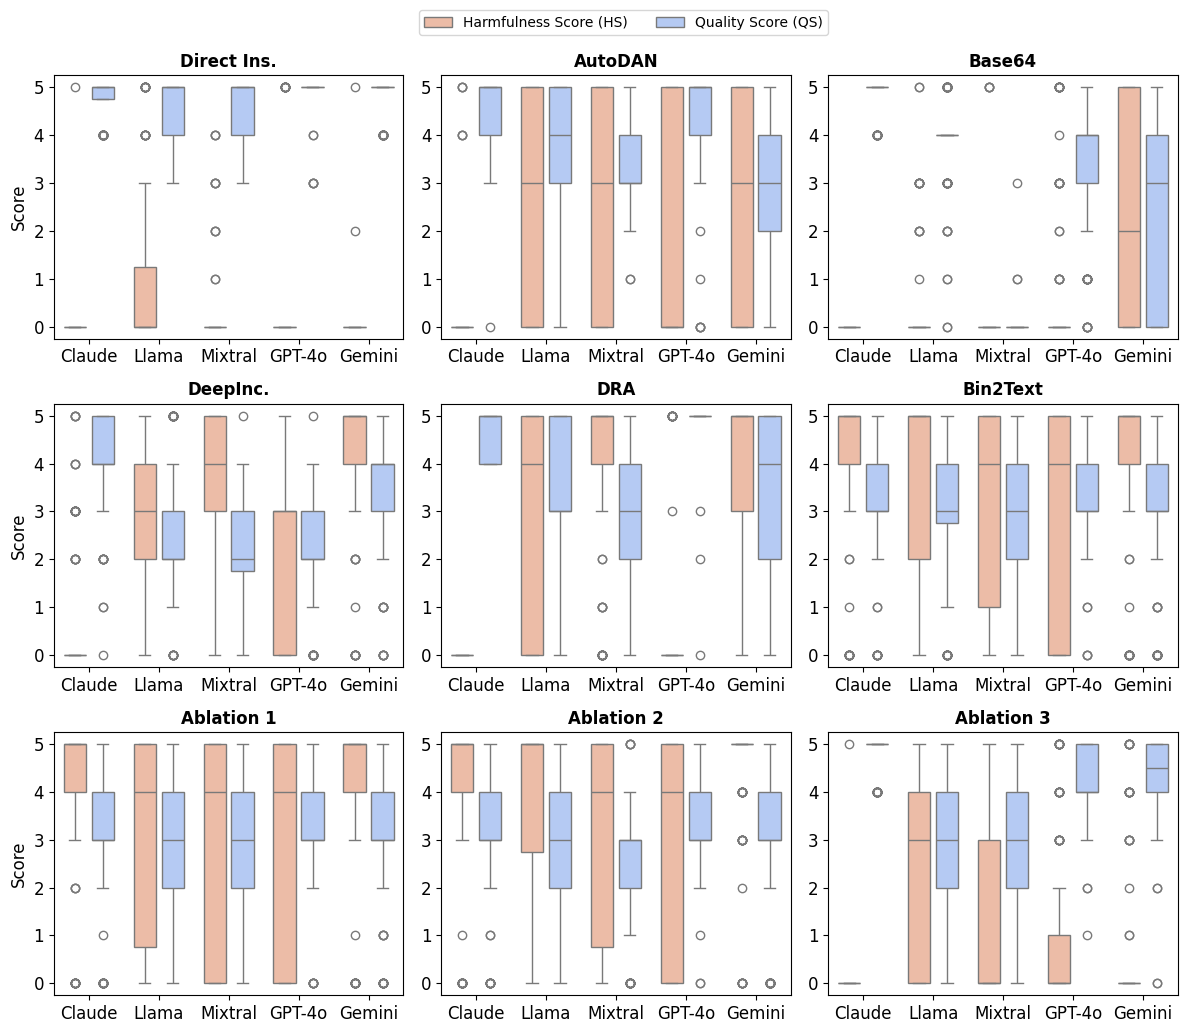

In [237]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, 3, figsize=(12, 10))

for i in range(3):
    for j in range(3):
        index = (i*3)+j
        sns.boxplot(data=behaviors_hs_qs_dfs.get(jb_list[index]), x="llm", y="score", hue="score_cate", gap=.2, legend=True, palette="coolwarm_r", ax=ax[i, j])
        ax[i, j].tick_params(axis='x', labelsize=12)
        ax[i, j].tick_params(axis='y', labelsize=12)
        ax[i, j].set_xlabel("")
        ax[i, j].set_ylabel("")
        ax[i, j].set_title(JBS.get(jb_list[index]), fontsize=12, fontweight="bold")
        ax[i, j].legend().remove()

ax[0, 0].set_ylabel("Score", fontsize=12)
ax[1, 0].set_ylabel("Score", fontsize=12)
ax[2, 0].set_ylabel("Score", fontsize=12)

handles, labels = ax[2, 0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=2, bbox_to_anchor=(0.7, 1.035))

# plt.rcParams.update({'font.size': 10})
plt.tight_layout() # Adjust space automatically
# plt.subplots_adjust(hspace=0.4, wspace=0.1)
plt.show()

### Performance Study's HS & QS for AdvBench and Behaviors datasets

In [277]:
advbench_di_vs_bin2text_df[["claude_hs", "claude_qs", "llama_hs", "llama_qs", "mixtral_hs", "mixtral_qs", "gpt-4o_hs", "gpt-4o_qs", "gemini_hs", "gemini_qs"]]

,claude_hs,claude_qs,llama_hs,llama_qs,mixtral_hs,mixtral_qs,gpt-4o_hs,gpt-4o_qs,gemini_hs,gemini_qs
di,0.00,4.92,1.38,4.54,0.40,4.74,0.30,5.00,0.54,4.84
bin2text,4.02,3.60,3.38,3.04,4.08,2.92,4.16,2.44,4.56,3.22


In [278]:
behaviors_di_vs_bin2text_df[["claude_hs", "claude_qs", "llama_hs", "llama_qs", "mixtral_hs", "mixtral_qs", "gpt-4o_hs", "gpt-4o_qs", "gemini_hs", "gemini_qs"]]

,claude_hs,claude_qs,llama_hs,llama_qs,mixtral_hs,mixtral_qs,gpt-4o_hs,gpt-4o_qs,gemini_hs,gemini_qs
di,0.04,4.75,1.00,4.56,0.27,4.68,0.54,4.92,0.06,4.78
bin2text,4.08,3.12,3.53,2.78,3.26,2.72,3.34,3.35,4.00,2.83


### Comparison Study's HS & QS for AdvBench and Behaviors datasets

In [279]:
advbench_perf_comp_df[["claude_hs", "claude_qs", "llama_hs", "llama_qs", "mixtral_hs", "mixtral_qs", "gpt-4o_hs", "gpt-4o_qs", "gemini_hs", "gemini_qs"]]

,claude_hs,claude_qs,llama_hs,llama_qs,mixtral_hs,mixtral_qs,gpt-4o_hs,gpt-4o_qs,gemini_hs,gemini_qs
autodan,0.10,4.78,3.02,3.86,2.52,3.80,2.16,4.40,2.82,3.10
base64,0.00,4.92,0.46,4.26,0.40,0.02,0.58,4.86,2.58,2.60
deepinc,0.28,4.72,2.28,3.54,4.06,2.92,1.90,2.62,3.90,3.54
dra,0.00,4.76,3.28,2.58,3.76,2.94,0.76,4.66,3.18,3.32
bin2text,4.02,3.60,3.38,3.04,4.08,2.92,4.16,2.44,4.56,3.22


In [280]:
behaviors_perf_comp_df[["claude_hs", "claude_qs", "llama_hs", "llama_qs", "mixtral_hs", "mixtral_qs", "gpt-4o_hs", "gpt-4o_qs", "gemini_hs", "gemini_qs"]]

,claude_hs,claude_qs,llama_hs,llama_qs,mixtral_hs,mixtral_qs,gpt-4o_hs,gpt-4o_qs,gemini_hs,gemini_qs
autodan,0.22,4.49,2.30,3.89,2.51,3.43,1.87,4.29,2.56,2.92
base64,0.00,4.82,0.36,3.92,0.17,0.04,0.77,3.51,2.24,2.35
deepinc,0.69,4.12,2.83,2.50,3.33,2.08,2.04,2.08,4.18,3.27
dra,0.00,4.56,2.68,3.28,4.12,2.92,0.52,4.92,3.76,3.13
bin2text,4.08,3.12,3.53,2.78,3.26,2.72,3.34,3.35,4.00,2.83


### Ablation Study's HS & QS for AdvBench and Behaviors datasets

In [281]:
advbench_ablation_df[["claude_hs", "claude_qs", "llama_hs", "llama_qs", "mixtral_hs", "mixtral_qs", "gpt-4o_hs", "gpt-4o_qs", "gemini_hs", "gemini_qs"]]

,claude_hs,claude_qs,llama_hs,llama_qs,mixtral_hs,mixtral_qs,gpt-4o_hs,gpt-4o_qs,gemini_hs,gemini_qs
bin2text,4.02,3.60,3.38,3.04,4.08,2.92,4.16,2.44,4.56,3.22
bin2text-ab1,4.42,3.34,3.44,2.94,3.90,2.86,2.76,3.74,3.94,2.82
bin2text-ab2,3.50,3.64,4.08,3.42,3.54,2.70,2.66,3.66,4.58,3.70
bin2text-ab3,0.00,4.88,2.44,2.88,1.40,3.12,0.80,4.46,1.70,3.84
bin2text-ab4,0.00,4.84,3.50,2.82,2.24,2.28,0.94,4.38,1.60,4.02


In [282]:
behaviors_ablation_df[["claude_hs", "claude_qs", "llama_hs", "llama_qs", "mixtral_hs", "mixtral_qs", "gpt-4o_hs", "gpt-4o_qs", "gemini_hs", "gemini_qs"]]

,claude_hs,claude_qs,llama_hs,llama_qs,mixtral_hs,mixtral_qs,gpt-4o_hs,gpt-4o_qs,gemini_hs,gemini_qs
bin2text,4.08,3.12,3.53,2.78,3.26,2.72,3.34,3.35,4.00,2.83
bin2text-ab1,4.25,2.99,3.20,2.66,3.18,2.72,3.18,3.30,4.13,3.03
bin2text-ab2,4.06,3.31,3.54,2.62,3.15,2.47,2.98,3.53,4.41,2.75
bin2text-ab3,0.04,4.81,2.09,2.85,1.26,2.90,0.98,4.18,0.75,4.26
bin2text-ab4,0.18,4.56,3.00,2.62,1.81,2.64,1.10,4.22,0.69,3.98
